<a href="https://colab.research.google.com/github/ldfha/RotemAI/blob/main/projects/pro13cnn/cnnquiz.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv2D, MaxPooling2D, Flatten, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)   # 필요에 따라 (128,128) 등으로 변경
BATCH    = 32
# /content/drive/MyDrive/Colab Notebooks/data/rock-paper-scissors
train_dir = "/content/drive/MyDrive/Colab Notebooks/data/rock-paper-scissors/train"
valid_dir = "/content/drive/MyDrive/Colab Notebooks/data/rock-paper-scissors/valid"
test_dir  = "/content/drive/MyDrive/Colab Notebooks/data/rock-paper-scissors/test"

# 디렉터리에서 이미지 분류용 데이터셋 만들기
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",             # [0..C-1] 정수 라벨
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True,
    seed=42,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=True,
    seed=42,
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH,
    shuffle=False
)
# 클래스 이름 확인
class_names = train_ds.class_names
print("class_names:", class_names)    # 예: ['paper', 'rock', 'scissors']
# --- feature와 label 일부 출력 ---
for images, labels in train_ds.take(1):
    print("features shape:", images.shape)   # (B, H, W, 3)
    print("labels shape:", labels.shape)     # (B,)
    print("labels (first 10):", labels[:10].numpy())
    print("labels mapped (first 10):", [class_names[i] for i in labels[:10].numpy()])


Found 2520 files belonging to 3 classes.
Found 372 files belonging to 3 classes.
class_names: ['paper', 'rock', 'scissors']
features shape: (32, 224, 224, 3)
labels shape: (32,)
labels (first 10): [2 1 0 2 2 1 0 1 1 1]
labels mapped (first 10): ['scissors', 'rock', 'paper', 'scissors', 'scissors', 'rock', 'paper', 'rock', 'rock', 'rock']


In [ ]:
# 이미지 증강/스케일링
IMG_HEIGHT, IMG_WIDTH = (150, 150)
BATCH_SIZE = 128
EPOCHS = 20

train_datagen = ImageDataGenerator(
    rescale=1./255,  # [0. ,1] 스케일(이미지 픽셀값을 0 ~ 1 사이로 조정)
    rotation_range=15,  # 회전
    width_shift_range=0.1,height_shift_range=0.1, # 평행 이동
    horizontal_flip=True,  # 좌우 반전
)
scale_data = ImageDataGenerator(rescale=1./255)  # 검증은 스케일만

train_data = scale_data.flow_from_directory(    # 증강 없는 train data
    train_dir,
    target_size = (IMG_HEIGHT, IMG_WIDTH),
    batch_size = BATCH_SIZE,
    class_mode = 'categorical',
    shuffle = True,
    seed = 42
)

train_data_aug = train_datagen.flow_from_directory(   # 증강 있는 train data
  train_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'categorical',
  shuffle = True,
  seed = 42
)

val_data = scale_data.flow_from_directory(   # 폴더를 자동 라벨링하여 로드
  valid_dir,
  target_size = (IMG_HEIGHT, IMG_WIDTH),
  batch_size = BATCH_SIZE,
  class_mode = 'categorical',
  shuffle=False
)

test_data = scale_data.flow_from_directory(
    test_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print('class_indices:', train_data_aug.class_indices)

Found 2520 images belonging to 3 classes.
Found 2520 images belonging to 3 classes.
Found 33 images belonging to 3 classes.
Found 372 images belonging to 3 classes.
class_indices: {'paper': 0, 'rock': 1, 'scissors': 2}


idx_to_name :  {0: 'paper', 1: 'rock', 2: 'scissors'}


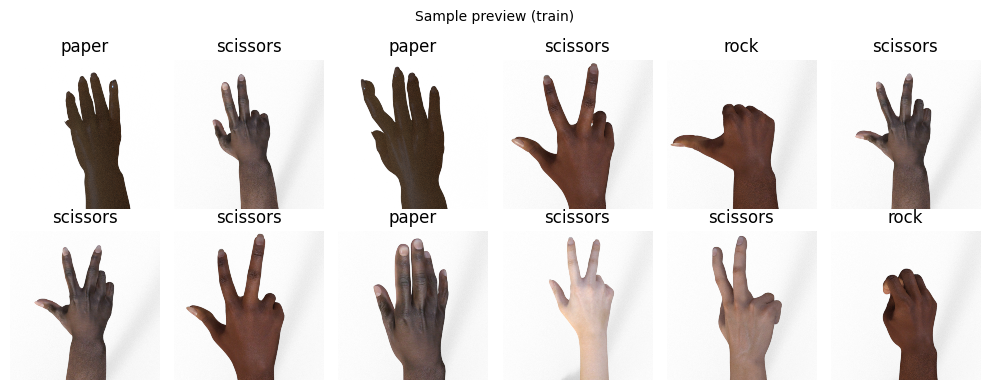

In [ ]:
# 로드된 이미지 미리보기 (한 배치)
imgs, labels = next(train_data)
n_show = min(12, imgs.shape[0]) # 보여줄 샘플 수
cols = 6
rows = int(np.ceil(n_show / cols))

idx_to_name = {v:k for k, v in train_data.class_indices.items() }
print('idx_to_name : ', idx_to_name)

plt.figure(figsize=(10, 2*rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(imgs[i])
  ax.set_title(f'{idx_to_name[np.argmax(labels[i])]}')
  plt.axis('off')
plt.suptitle('Sample preview (train)', fontsize=10)
plt.tight_layout()
plt.show()

idx_to_name :  {0: 'paper', 1: 'rock', 2: 'scissors'}


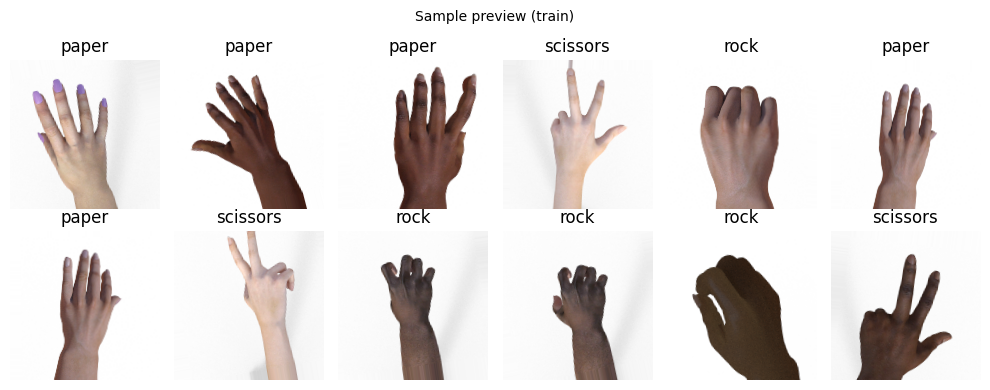

In [ ]:
# 증강된 이미지
imgs, labels = next(train_data_aug)
n_show = min(12, imgs.shape[0]) # 보여줄 샘플 수
cols = 6
rows = int(np.ceil(n_show / cols))

idx_to_name = {v:k for k, v in train_data_aug.class_indices.items() }
print('idx_to_name : ', idx_to_name)

plt.figure(figsize=(10, 2*rows))
for i in range(n_show):
  ax = plt.subplot(rows, cols, i+1)
  ax.imshow(imgs[i])
  ax.set_title(f'{idx_to_name[np.argmax(labels[i])]}')
  plt.axis('off')
plt.suptitle('Sample preview (train)', fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
# model
def build_model():
    model = Sequential([
        Input((IMG_HEIGHT, IMG_WIDTH, 3)),

        Conv2D(16, 3, padding='same', activation='relu'),
        MaxPooling2D(),

        Conv2D(32, 3, padding='same', activation='relu'),
        MaxPooling2D(),

        Conv2D(64, 3, padding='same', activation='relu'),
        MaxPooling2D(),

        Flatten(),

        Dense(128, activation='relu'),
        Dropout(0.3),
        Dense(3, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

model_no_aug = build_model()
model_aug = build_model()
print(model_no_aug.summary())

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     2,654,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,678,307 (10.22 MB)

 Trainable params: 2,678,307 (10.22 MB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
import os
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 증강 없는 데이터셋으로 만든 모델
model_no_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

os.makedirs('chkpoints', exist_ok=True)

ckpt_no_aug = ModelCheckpoint(
    filepath= 'chkpoints/quiz_no_aug.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
)
es_no_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_no_aug = model_no_aug.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[ckpt_no_aug, es_no_aug], verbose=2
)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.66667, saving model to chkpoints/quiz_no_aug.keras

Epoch 1: finished saving model to chkpoints/quiz_no_aug.keras
20/20 - 54s - 3s/step - accuracy: 0.5532 - loss: 0.9646 - val_accuracy: 0.6667 - val_loss: 0.7577
Epoch 2/20

Epoch 2: val_accuracy improved from 0.66667 to 0.84848, saving model to chkpoints/quiz_no_aug.keras

Epoch 2: finished saving model to chkpoints/quiz_no_aug.keras
20/20 - 17s - 825ms/step - accuracy: 0.9210 - loss: 0.2572 - val_accuracy: 0.8485 - val_loss: 0.3973
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.84848
20/20 - 15s - 768ms/step - accuracy: 0.9929 - loss: 0.0341 - val_accuracy: 0.8182 - val_loss: 0.3263
Epoch 4/20

Epoch 4: val_accuracy improved from 0.84848 to 0.87879, saving model to chkpoints/quiz_no_aug.keras

Epoch 4: finished saving model to chkpoints/quiz_no_aug.keras
20/20 - 15s - 761ms/step - accuracy: 0.9984 - loss: 0.0107 - val_accuracy: 0.8788 - val_loss: 0.2818
Epoch 5/20

Ep

In [ ]:
# 증강 O
model_aug.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

os.makedirs('chkpoints', exist_ok=True)

ckpt_aug = ModelCheckpoint(
    filepath= 'chkpoints/quiz_aug.keras',
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    mode='max',
)

es_aug = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_aug = model_aug.fit(
    train_data_aug,
    validation_data=val_data,
    epochs=EPOCHS,
    callbacks=[ckpt_aug, es_aug], verbose=2
)

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.54545, saving model to chkpoints/quiz_aug.keras

Epoch 1: finished saving model to chkpoints/quiz_aug.keras
20/20 - 35s - 2s/step - accuracy: 0.4155 - loss: 1.2417 - val_accuracy: 0.5455 - val_loss: 0.9498
Epoch 2/20

Epoch 2: val_accuracy improved from 0.54545 to 0.78788, saving model to chkpoints/quiz_aug.keras

Epoch 2: finished saving model to chkpoints/quiz_aug.keras
20/20 - 29s - 1s/step - accuracy: 0.7004 - loss: 0.7512 - val_accuracy: 0.7879 - val_loss: 0.4203
Epoch 3/20

Epoch 3: val_accuracy improved from 0.78788 to 0.96970, saving model to chkpoints/quiz_aug.keras

Epoch 3: finished saving model to chkpoints/quiz_aug.keras
20/20 - 29s - 1s/step - accuracy: 0.8861 - loss: 0.3124 - val_accuracy: 0.9697 - val_loss: 0.1930
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.96970
20/20 - 29s - 1s/step - accuracy: 0.9567 - loss: 0.1486 - val_accuracy: 0.8182 - val_loss: 0.2689
Epoch 5/20

Epoch 5: val_accuracy did not

증강 X 검증 평가 결과 : loss : 0.2818, acc : 0.8788
증강 O 검증 평가 결과 : loss : 0.0525, acc : 1.0000


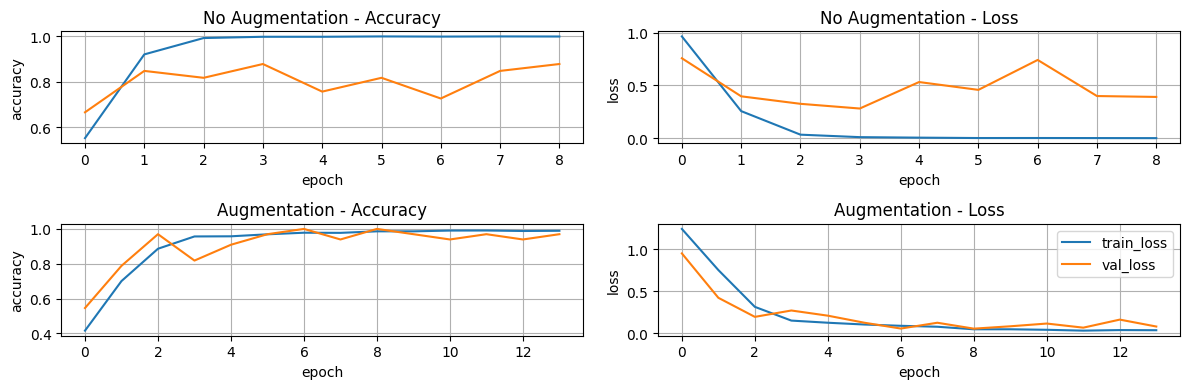

In [ ]:
# 평가 / 시각화
val_no_loss, val_no_acc = model_no_aug.evaluate(val_data, verbose = 0)
print(f'증강 X 검증 평가 결과 : loss : {val_no_loss:.4f}, acc : {val_no_acc:.4f}')
val_loss, val_acc = model_aug.evaluate(val_data, verbose = 0)
print(f'증강 O 검증 평가 결과 : loss : {val_loss:.4f}, acc : {val_acc:.4f}')

plt.figure(figsize=(12, 4))
plt.subplot(2, 2, 1)
plt.plot(history_no_aug.history['accuracy'], label='train_acc')
plt.plot(history_no_aug.history['val_accuracy'], label='val_acc')
plt.title('No Augmentation - Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)

plt.subplot(2, 2, 2)
plt.plot(history_no_aug.history['loss'], label='train_loss')
plt.plot(history_no_aug.history['val_loss'], label='val_loss')
plt.title('No Augmentation - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

plt.subplot(2, 2, 3)
plt.plot(history_aug.history['accuracy'], label='train_acc')
plt.plot(history_aug.history['val_accuracy'], label='val_acc')
plt.title('Augmentation - Accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)

plt.subplot(2, 2, 4)
plt.plot(history_aug.history['loss'], label='train_loss')
plt.plot(history_aug.history['val_loss'], label='val_loss')
plt.title('Augmentation - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.grid(True)

plt.tight_layout()
plt.legend()
plt.show()

전체 test 이미지 수: 372
클래스 분포: [124 124 124]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 491ms/step
실제 클래스: ['paper', 'rock', 'rock', 'paper', 'rock', 'scissors', 'rock', 'rock', 'paper', 'scissors']
증강 X 예측: ['paper', 'rock', 'rock', 'paper', 'rock', 'scissors', 'rock', 'rock', 'rock', 'scissors']
증강 O 예측: ['paper', 'rock', 'rock', 'rock', 'rock', 'scissors', 'rock', 'rock', 'paper', 'scissors']


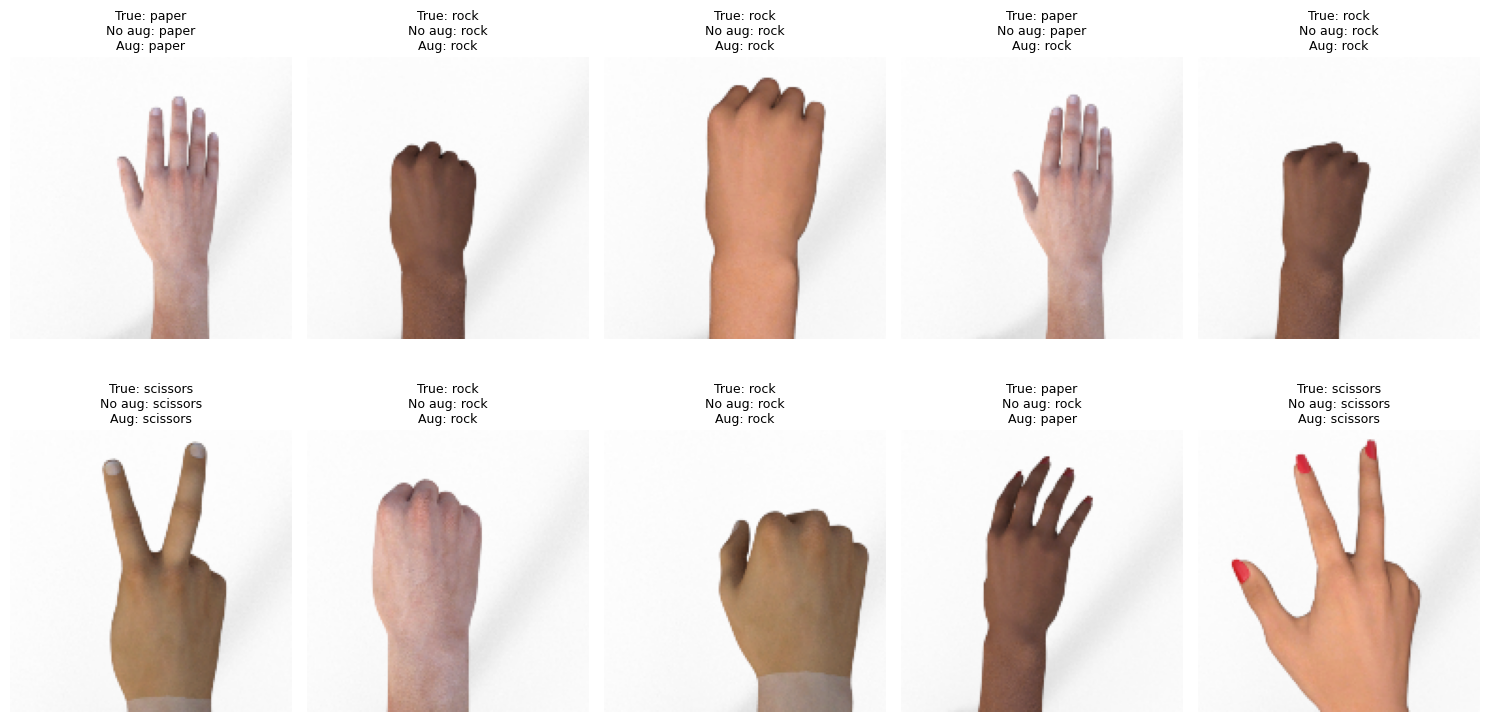

In [ ]:
all_imgs = []
all_labels = []

for i in range(len(test_data)):
    imgs_batch, labels_batch = next(test_data)
    all_imgs.append(imgs_batch)
    all_labels.append(labels_batch)

all_imgs = np.concatenate(all_imgs, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

true_labels = np.argmax(all_labels, axis=1)

print("전체 test 이미지 수:", len(all_imgs))
print("클래스 분포:", np.bincount(true_labels))

# 랜덤 10장 선택
np.random.seed(42)
sample_idx = np.random.choice(len(all_imgs), size=10, replace=False)

sample_imgs = all_imgs[sample_idx]
sample_true_labels = true_labels[sample_idx]

# 증강 X 모델 예측
pred_no_aug = model_no_aug.predict(sample_imgs)
pred_no_aug_labels = np.argmax(pred_no_aug, axis=1)

# 증강 O 모델 예측
pred_aug = model_aug.predict(sample_imgs)
pred_aug_labels = np.argmax(pred_aug, axis=1)

print("실제 클래스:", [idx_to_name[i] for i in sample_true_labels])
print("증강 X 예측:", [idx_to_name[i] for i in pred_no_aug_labels])
print("증강 O 예측:", [idx_to_name[i] for i in pred_aug_labels])

plt.figure(figsize=(15, 8))

for i in range(10):
    ax = plt.subplot(2, 5, i + 1)
    ax.imshow(sample_imgs[i])

    true_name = idx_to_name[sample_true_labels[i]]
    no_aug_name = idx_to_name[pred_no_aug_labels[i]]
    aug_name = idx_to_name[pred_aug_labels[i]]

    ax.set_title(
        f"True: {true_name}\nNo aug: {no_aug_name}\nAug: {aug_name}",
        fontsize=9
    )
    plt.axis("off")

plt.tight_layout()
plt.show()